<a href="https://colab.research.google.com/github/Dirga36/Streamlit-test/blob/main/ML_test_2nd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix

from google.colab import drive
import sys
import os
drive.mount('/content/gdrive')
drivePath = ('/content/gdrive/My Drive/Colab Notebooks/dataset_1st') # sesuaikan direktori Drive
sys.path.append(drivePath)
os.chdir(drivePath)
current_dir = os.getcwd()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# Import dataset

data = pd.read_csv ("diabetes.csv") # sesuaikan file dataset
df = pd.DataFrame (data)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


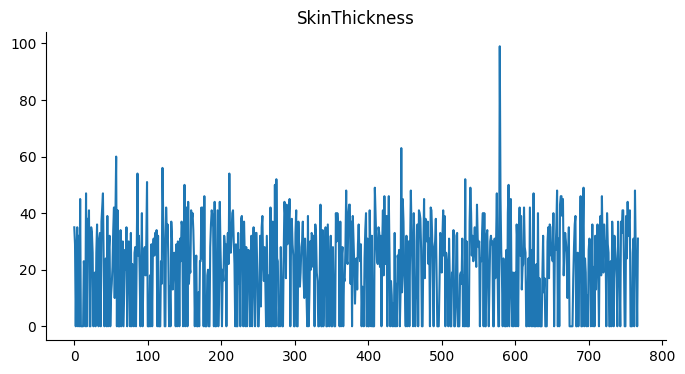

In [ ]:
# @title SkinThickness

from matplotlib import pyplot as plt
df['SkinThickness'].plot(kind='line', figsize=(8, 4), title='SkinThickness')
plt.gca().spines[['top', 'right']].set_visible(False)

# EDA (Exploratory Data Analysis)

In [ ]:
# Menampilkan jumlah baris data dan jumlah kolom

print ("Shape of data {}" . format (df.shape))
print ("Number of rows: {}" . format (df.shape [0]))
print ("Number of columns: {}" . format (df.shape [1]))

Shape of data (768, 9)
Number of rows: 768
Number of columns: 9


In [ ]:
# Menampilkan ringkasan informasi tentang data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Menampilkan statistik deskriptif dari kolom numerik pada data

# df.describe()

In [ ]:
# Menampilkan statistik deskriptif dari kolom numerik pada data

# df.describe()

In [ ]:
# Menampilkan nilai korelasi antar kolom

## df.corr()

<Axes: title={'center': 'Correlation Graph'}>

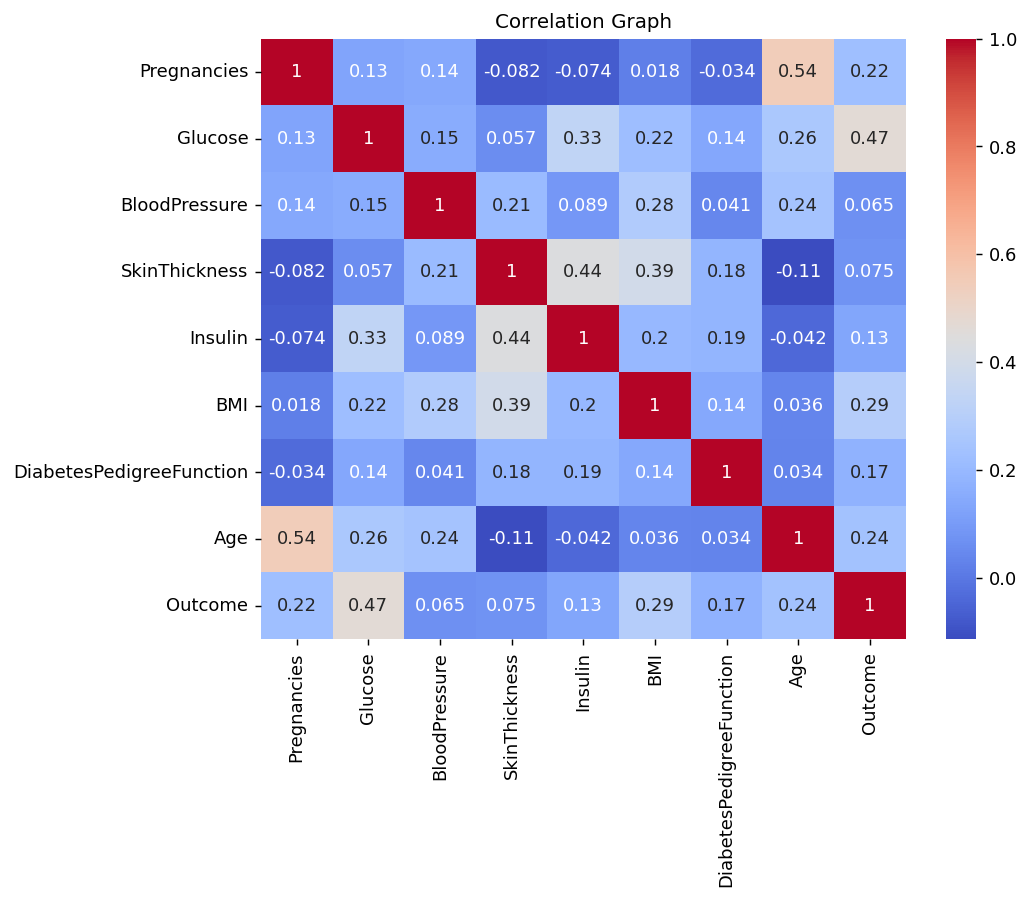

In [ ]:
# Memvisualisasikan hubungan korelasi antar kolom

plt.figure (figsize = [8,6],  dpi = 130 )
plt.title ("Correlation Graph" , fontsize = 11 )
sns.heatmap (df.corr(), annot = True , cmap="coolwarm" )

# Preprocessing

In [ ]:
# Mengecek nilai null dan missing value dalam data

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
# Mengecek jumlah data duplikast dalam data

print ("Jumlah data duplikat:" , df.duplicated().sum())

Jumlah data duplikat: 0


In [ ]:
# Menentukan nilai x sebagai fitur atau kolom yang akan dijadikan penentu prediksi

X = pd.DataFrame (data , columns = ["Pregnancies" , "Glucose" , "BloodPressure" , "SkinThickness" , "Insulin" , "BMI", "DiabetesPedigreeFunction" , "Age"])

# Menentukan nilai y sebagai kolom yang akan diprediksi

y = data.Outcome

# Membangun Model Prediksi

In [ ]:
# Membagi ke dalam data train dan data testing

X_train , X_test , y_train , y_test = train_test_split (X , y , test_size = 0.25 , random_state = 0)

In [ ]:
# Melatih model dengan algoritma Logistic Regression

logreg = LogisticRegression (solver = "liblinear")

logreg.fit (X_train , y_train)
y_pred = logreg.predict(X_test)
y_predicted_proba = logreg.predict_proba(X_test)

In [ ]:
# Menampilkan evaluasi akurasi dari model yang dibuat

print ("Accuracy: " , metrics.accuracy_score (y_test , y_pred))

Accuracy:  0.8072916666666666


In [ ]:
# Menampilkan evaluasi confusion matrix dari model yang dibuat

confusion_matrix (y , logreg.predict (X))

array([[443,  57],
       [120, 148]])

In [ ]:
# Menampilkan evaluasi classification report dari model yang dibuat

print (classification_report (y , logreg.predict (X)))

              precision    recall  f1-score   support

           0       0.79      0.89      0.83       500
           1       0.72      0.55      0.63       268

    accuracy                           0.77       768
   macro avg       0.75      0.72      0.73       768
weighted avg       0.76      0.77      0.76       768



# Mencoba Memprediksi Diabetes Dengan Data Baru

In [ ]:
# Contoh data baru (diacak)

import pandas as pd
import numpy as np

# Generate data
data_baru = pd.DataFrame({
    'Pregnancies': [np.random.randint(0, 17)],
    'Glucose': [np.random.randint(70, 200)],
    'BloodPressure': [np.random.randint(40, 122)],
    'SkinThickness': [np.random.randint(7, 99)],
    'Insulin': [np.random.randint(0, 846)],
    'BMI': [np.round(np.random.uniform(18.0, 67.0), 1)],
    'DiabetesPedigreeFunction': [np.round(np.random.uniform(0.08, 2.5), 3)],
    'Age': [np.random.randint(21, 81)]
})

# Tampilkan sebagai tabel
data_baru.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,15,175,53,49,363,64.3,1.763,37


In [ ]:
# Contoh data baru

data_baru = pd.DataFrame({
    'Pregnancies': [25],
    'Glucose': [75],
    'BloodPressure': [90],
    'SkinThickness': [45],
    'Insulin': [0],
    'BMI': [33.6],
    'DiabetesPedigreeFunction': [0.627],
    'Age': [50]
})

# Memprediksi data baru dengan model yang dibuat sebelumnya
prediksi_baru = logreg.predict(data_baru) # atau gunakan data_acak

# Menampilkan hasil prediksi
if prediksi_baru[0] == 1:
    print("Hasil prediksi: Diabetes")
else:
    print("Hasil prediksi: Tidak Diabetes")

Hasil prediksi: Diabetes
